In [1]:
import struct
import numpy as np
import subprocess
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
#from tqdm.notebook import tqdm # Progress bar
from matplotlib import colormaps as cm

In [2]:
FONTSIZE=18
FIGSIZE=(8,8)

FIGURE_FOLDER = 'figures/'
DATA_FOLDER = 'out/'

TSTEP = 0.001

In [3]:
KILLRANGE = [1e-6,50]
# Run our C code by calling the shell with arguments
def getTrajectory(v0, theta, N=1_000, tstep=0.00001, 
                  method='verlet', x0=[0.0,0.058],
                  fname = 'tmp.bin'):
    filename = DATA_FOLDER + fname
    v0_vec = [v0*np.cos(theta), v0*np.sin(theta)]
    # Run the simulation with all options
    result = subprocess.run(['./simulation',
                             '-v', '%f,%f' % tuple(v0_vec), # Set Velocity
                             '-r', '%f,%f' % tuple(x0),     # Set Position
                             '-n', '%d'    % N,             # Num steps
                             '-t', '%f'    % tstep,         # Step-size
                             '-s', '%d'    % 1,             # Save skip (save every %d),
                             #'-k', '%f,%f' % tuple(KILLRANGE),
                             '-o', filename,                # Output file name
                             '-b', '1',                     # Enable binary output (because fast)
                             '-m', method,                  # Choose our integration method here,
                             '-f', 'circular_restricted'],   # Choice of CR3BP force,
                           capture_output=True )   # Silence output of C program
    # Read back the output, return it
    return read_binary_file(filename)

# Read the output file generated by our C code
def read_binary_file(filename):
    with open(filename, 'rb') as file:
        numSteps, numColumns = struct.unpack('ii', file.read(8))
        data = []
        # Read the input array (first "column")
        inputArray = np.fromfile(file, dtype=np.double, count=numSteps)
        data.append(inputArray)
        # Read each subsequent data array ("column")
        for _ in range(numColumns):
            dataArray = np.fromfile(file, dtype=np.double, count=numSteps)
            data.append(dataArray)
    return data

In [4]:
# Rotation matrix with (t)->(-t) 
def rotatePaths(x,y,t):
    return [ np.cos(t)*x + np.sin(t)*y, 
            -np.sin(t)*x + np.cos(t)*y]

In [5]:
# Handy Plot Functions

def bigTicks(size=14):
    '''Function to increase font size of "tick" labels.'''
    plt.gca().tick_params(axis='both', which='major', labelsize=size)
    
def drawAxisLines(**kwargs):
    '''Make the x=0 and y=0 axes really apparent'''
    ax = plt.gca()
    args = {}
    args['color'] = 'k'
    args['alpha'] = 0.5
    args['lw'] = 1
    for k,v in kwargs.items():
        args[k] = v
    ax.axhline(y=0, **args)
    ax.axvline(x=0, **args)
    

def savefig(savename, img_format='.svg'):
    '''Standardize the saving of plots to designated folder.'''
    kwargs = {}
    kwargs.setdefault('bbox_inches', 'tight')
    if(img_format == '.png'):
        kwargs['dpi'] = 300
    plt.savefig(FIGURE_FOLDER + savename + img_format, **kwargs)
    

def plotSliced(x, y, numSlices=100, color_vect=[1,0,0], 
                                   color_range=[0.25,1.0],
                                   color_curv = 0.01,
                                   alpha_range=[1,1],
                                   overlap_int = 1):
    '''Slice up the plot and give a diffent color for each'''
    N = len(x)
    N_C = numSlices #Number of slices
    crng = np.array(color_range)*color_curv
    cr = np.geomspace(*crng,N_C)/color_curv # Green color range
    ar = np.geomspace(*alpha_range,N_C) # Green color range
    slices = np.round(np.linspace(0,N,N_C)[:-1]).astype(int)
    plotstep = round(N/N_C)+overlap_int
    for i in range(N_C-1):
        ps = plotstep
        if(ar[i] > 0.6):
            ps = plotstep+1
        ind = slices[i]
        plt.plot(x[ind:ind+ps], y[ind:ind+ps],alpha=ar[i],
                                        color=np.array(color_vect)*cr[i])

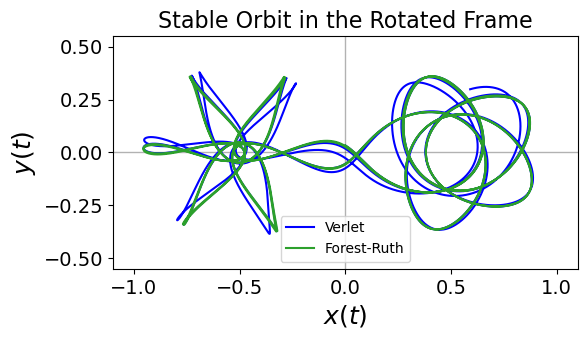

In [6]:
plt.figure(figsize=(6,6))
plt.axis('scaled')
drawAxisLines(alpha=0.3)
v0=0.4380
theta = -0.59
TSTEP = 0.001

plotOpts = {'alpha_range' : [1,1],
            'color_range' : [0.8,.8],
            'numSlices' : 1000,
            'overlap_int' : 0}

simOpts = {'tstep' : TSTEP,
           'N'     : 9*np.pi//TSTEP,  # integer number of binary orbits completed
           'x0' : [0, 0.032857]}

dats = []

dat = getTrajectory(v0, theta, method = 'verlet', **simOpts)
t, x, y, vx, vy = dat
dats.append(dat)
x_rot, y_rot = rotatePaths(x,y,t)
#plotSliced(x_rot, y_rot, color_vect=[0,0,1], **plotOpts)
plt.plot(x_rot, y_rot, c='blue', label='Verlet')

dat = getTrajectory(v0, theta, method = 'fr_pv', **simOpts)
t, x, y, vx, vy = dat
dats.append(dat)
x_rot, y_rot = rotatePaths(x,y,t)
#plotSliced(x_rot, y_rot, color_vect=[0,1,0], **plotOpts)
plt.plot(x_rot, y_rot, c='tab:green', label='Forest-Ruth')


#plt.plot([x_rot[-1]],[y_rot[-1]], 'o', c='red')
#plt.plot([x[0]],[y[0]], 'o', c='blue')

plt.xlabel("$x(t)$", size=18)
plt.ylabel("$y(t)$", size=18)
bigTicks()
zoom = 1.1
plt.xlim(-zoom, zoom)
plt.ylim(-zoom/2, zoom/2)
plt.legend()

plt.title("Stable Orbit in the Rotated Frame", size=16)
savefig('orbit_cr3bp')

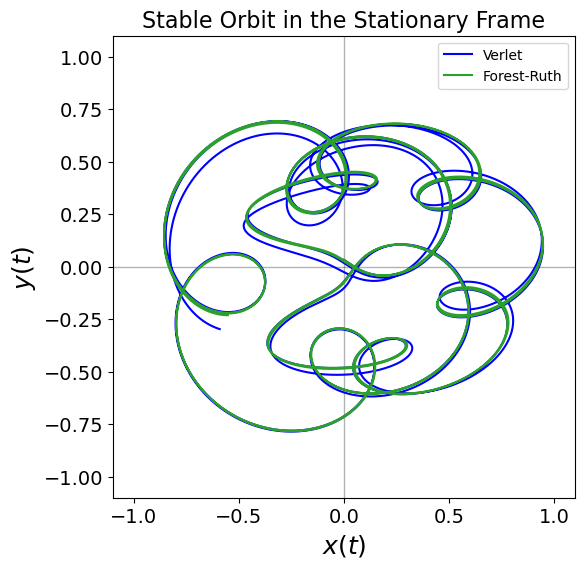

In [7]:
plt.figure(figsize=(6,6))
plt.axis('scaled')
drawAxisLines(alpha=0.3)
v0=0.4380
theta = -0.59
TSTEP = 0.001

plotOpts = {'alpha_range' : [1,1],
            'color_range' : [0.8,.8],
            'numSlices' : 1000,
            'overlap_int' : 0}

simOpts = {'tstep' : TSTEP,
           'N'     : 9*np.pi//TSTEP,  # integer number of binary orbits completed
           'x0' : [0, 0.032857]}

dats = []

dat = getTrajectory(v0, theta, method = 'verlet', **simOpts)
t, x, y, vx, vy = dat
dats.append(dat)
x_rot, y_rot = x, y
#plotSliced(x_rot, y_rot, color_vect=[0,0,1], **plotOpts)
plt.plot(x_rot, y_rot, c='blue', label='Verlet')

dat = getTrajectory(v0, theta, method = 'fr_pv', **simOpts)
t, x, y, vx, vy = dat
dats.append(dat)
x_rot, y_rot = x, y
#plotSliced(x_rot, y_rot, color_vect=[0,1,0], **plotOpts)
plt.plot(x_rot, y_rot, c='tab:green', label='Forest-Ruth')


#plt.plot([x_rot[-1]],[y_rot[-1]], 'o', c='red')
#plt.plot([x[0]],[y[0]], 'o', c='blue')

plt.xlabel("$x(t)$", size=18)
plt.ylabel("$y(t)$", size=18)
bigTicks()
zoom = 1.1
plt.xlim(-zoom, zoom)
plt.ylim(-zoom, zoom)
plt.legend()

plt.title("Stable Orbit in the Stationary Frame", size=16)
savefig('orbit_cr3bp_stat')